# 회귀

## 1. 회귀 소개

지도학습은 두 가지 유형으로 나뉨 = 분류와 회귀

분류는 예측값이 카테고리와 같은 이산형 클래스 값이고, 회귀는 연속형 숫자 값임.

## 2. 단순 선형 회귀를 통한 회귀 이해

단순 선형회귀는 독립변수와 종속변수가 각각 하나인 선형회귀 모델임

독립변수와 종속 변수 간 비례관계를 일차식 형태로 표현하고, 이를 기울기와 절편을 통해서 나타냄

실제 값과 회귀 모델의 차이에 따른 오류 값을 잔차라고 하며, 최적의 회귀 모델을 만든다는 것은 전체 데이터의 잔차가 최소가 되는 모델임을 의미함

오류값은 + 혹은 -가 될 수 있으며, 절댓값을 취하거나, 제곱을 구하여 더하는 방식을 사용함

전자의 경우 MAE(Mean Absolute Error), 후자의 경우 RSS(Residual Sum of Squre)라고 칭함

일반적으로 미분등의 계산을 편리하게 하기 위해 RSS 방식을 많이 사용함

RSS는 변수가 w_0, w_1인 식으로 표현할 수 있으며, 이 RSS를 최소로 하는 회귀 계수를 학습을 통해서 찾는 것이 머신러닝 기반 회귀의 핵심 사항임

RSS는 회귀계수가 중심변수가 되며, 독립변수 x와 종속변수 y는 상수로 취급함을 유의해야함.

RSS는 다음과 같은 정규식으로 표현가능

$$RSS(w_0,w_1) = \frac{1}{N} \displaystyle\sum_{i=1}^{N}(y_i-(w_0+w_1*x_i))^2
$$  

회귀에서 이 RSS는 비용(Cost)이며, 회귀계수로 구성되는 RSS를 비용함수라고 함

머신러닝 회귀 알고리즘은 데이터를 계속 학습하면서 비용함수가 리턴하는 값을 지속해서 감소시켜 최소의 오류값을 구하는 것을 목표로 함

## 3.비용 최소화하기 - 경사 하강법(Gradient Descent) 소개

비용함수 (손실함수)가 최소가 되는 w 파라미터를 구하는 방법으로 경사하강법이 있음

비용함수가 포물선 형태의 2차 함수라면 경사하강법은 최초 w에서부터 미분을 적용한 뒤 미분된 1차 함수의 기울기가 감소하지 않을 때까지 w값을 업데이트 함. 이후 기울기가 감소하지 않는 지점을 최소인 지점으로 간주하고 그 w를 리턴함. (최고차항계수가 양수일때의 극소값을 찾는 문제와 같음.)

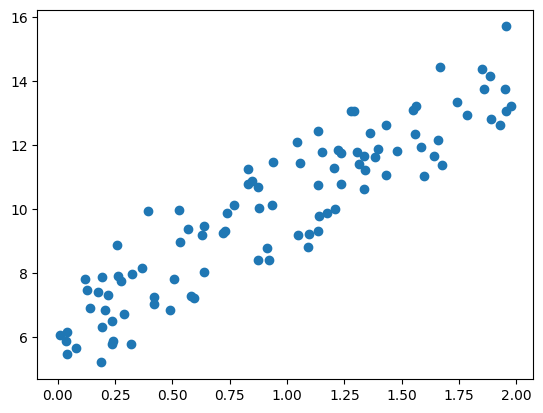

In [27]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
# y = 4x + 6을 근사(w1=4, w0=6). 임의의 값은 노이즈를 위해 만듦.
X = 2 * np.random.rand(100,1)
y = 6 + 4* X +np.random.randn(100,1)

# x,y 데이터 세트 산점도로 시각화

plt.scatter(x,y)

In [29]:
# 비용함수 get_cost()는 실제 y 값과 예측된 y값을 인자로 받아서 RSS를 계산하여 반환함.
def get_cost(y,y_pred):
    N = len(y)
    cost = np.sum(np.square(y - y_pred))/N
    return cost

In [32]:
# w1과 w0을 업데이트할 w1_update, w0_update를 반환.
def get_weight_updates(w1,w0,X,y,learning_rate=0.01):
    N = len(y)
    # 먼저 w1_update, w0_update를 각각 w1, w0의 shape와 동일한 크기를 가진 0 값으로 초기화
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)
    #예측 배열 계산하고 예측과 실제 값의 차이 계산
    y_pred = np.dot(X,w1.T) + w0
    diff = y-y_pred
    #w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
    w0_factors = np.ones((N,1))

    #w1과 w0을 업데이트할 w1_update와 w0_update 계산
    w1_update = -(2/N)*learning_rate*(np.dot(X.T, diff))
    w0_update = -(2/N)*learning_rate*(np.dot(w0_factors.T,diff))

    return w1_update, w0_update



In [33]:
def gradient_descent_steps(X,y, iters=10000):
    # w0와 w1을 모두 0으로 초기화.
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))

    #인자로 주어진 iters 만큼 반복적으로 get_weight_updates() 호출해 w1, w0 업데이트 수행
    for ind in range(iters):
        w1_update, w0_update = get_weight_updates(w1,w0,X,y,learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
    return w1, w0


이제 gradient_descent_steps()를 호출해 w1과 을 구하고, 예측값과 실제값의 RSS 차이를 계산하는 get_cost 함수로 예측 오류또한 계산

In [34]:
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y - y_pred))/N
    return cost
w1, w0 = gradient_descent_steps(X, y ,iters=1000)
print("w1:{0:.3f} w0:{1:.3f}".format(w1[0, 0], w0[0, 0]))
y_pred = w1[0,0] * X + w0
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y,y_pred)))

w1:4.022 w0:6.162
Gradient Descent Total Cost:0.9935


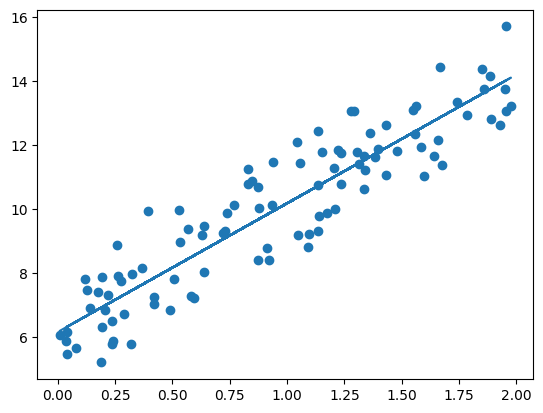

In [35]:
#앞에서 구한 y_pred에 기반해 회귀선을 그려봄
plt.scatter(X, y)
plt.plot(X, y_pred)

일반적으로 경사 하강법은 모든 학습 데이터에 대해 반복적으로 비용함수 최소화를 위한값을 업데이트하기 때문에 수행 시간이 매우 오래걸린다는 단점이 존재함. =>그래서 실전에서는 대부분 확률적 경사 하강법을 사용함.

확률적 경사 하강법은 전체 입력 데이터로 w가 업데이트되는 값을 계산하는 것이 아니라 일부 데이터만 이용해 w가 업데이트되는 값을 계산하여 비교적 빠른 속도를 보장함.

In [37]:
def stochastic_gradient_descent_steps(X, y, batch_size=10, iters=1000):
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    prev_cost = 100000
    iter_index =0
    
    for ind in range(iters):
        np.random.seed(ind)
        # 전체 X, y 데이터에서 랜덤하게 batch_size만큼 데이터 추출하여 sample_X, sample_y로 저장
        stochastic_random_index = np.random.permutation(X.shape[0])
        sample_X = X[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]
        # 랜덤하게 batch_size만큼 추출된 데이터 기반으로 w1_update, w0_update 계산 후 업데이트
        w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
    
    return w1, w0

이렇게 만들어진 stochastic_gradient_descent_steps()를 이용해 w1,w0 및 예측 오류 비용을 계산

In [38]:
w1, w0 = stochastic_gradient_descent_steps(X, y, iters=1000)
print("w1:",round(w1[0,0],3),"w0:",round(w0[0,0],3))
y_pred = w1[0,0] * X + w0
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1: 4.028 w0: 6.156
Stochastic Gradient Descent Total Cost:0.9937


일반 경사 하강법으로 구한 예측 오류 비용과 큰 차이가 없음. 따라서 큰 데이터를 처리할 경우에는 일반적으로 확률적 경사 하강법을 이용함.

다중 선형 회귀 여기 알아놓기

## 4.사이킷런 LinearRegression을 이용한 보스턴 주택 가격 예측

### LinearRegression

sicitlearn linear regression

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_boston
import warnings
warnings.filterwarnings('ignore')  #사이킷런 1.2 부터는 보스턴 주택가격 데이터가 없어진다는 warning 메시지 출력 제거
%matplotlib inline

# boston 데이타셋 로드
boston = load_boston()

# boston 데이타셋 DataFrame 변환 
bostonDF = pd.DataFrame(boston.data , columns = boston.feature_names)

# boston dataset의 target array는 주택 가격임. 이를 PRICE 컬럼으로 DataFrame에 추가함. 
bostonDF['PRICE'] = boston.target
print('Boston 데이타셋 크기 :',bostonDF.shape)
bostonDF.head()

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

NameError: name 'bostonDF' is not defined

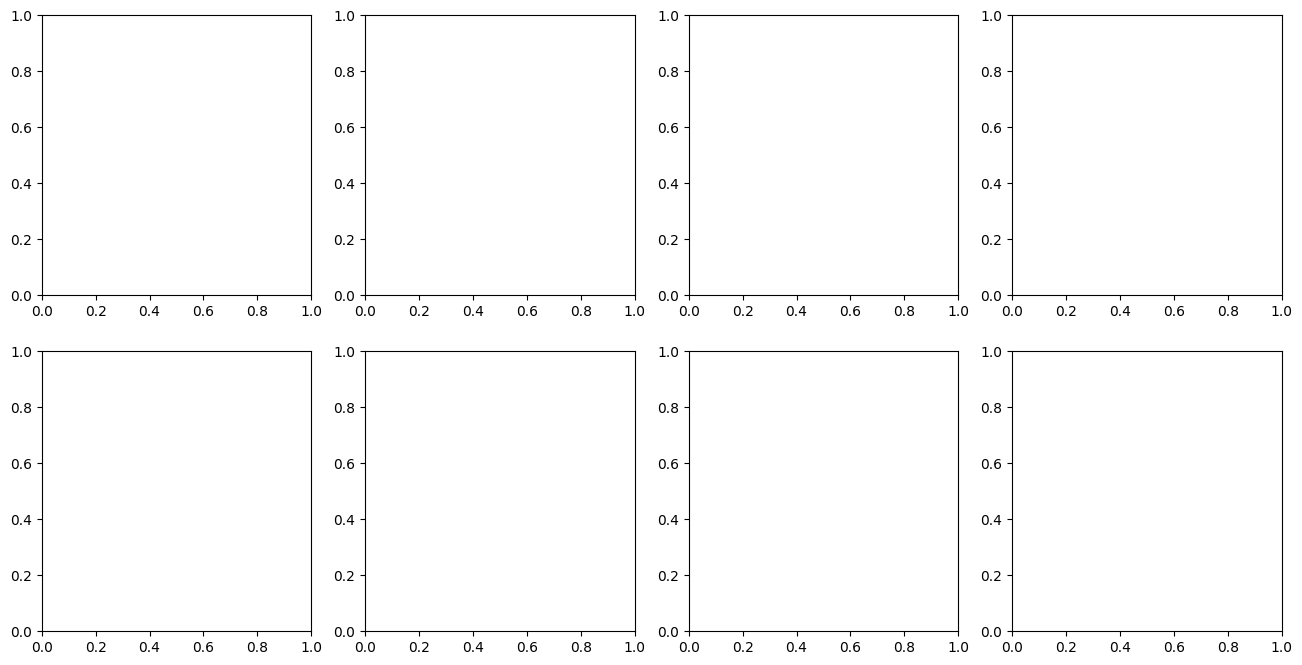

In [42]:
# 2개의 행과 4개의 열을 가진 subplots를 이용. axs는 4x2개의 ax를 가짐.
fig, axs = plt.subplots(figsize=(16,8) , ncols=4 , nrows=2)
lm_features = ['RM','ZN','INDUS','NOX','AGE','PTRATIO','LSTAT','RAD']
for i , feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    # 시본의 regplot을 이용해 산점도와 선형 회귀 직선을 함께 표현
    sns.regplot(x=feature , y='PRICE',data=bostonDF , ax=axs[row][col])

fig1 = plt.gcf()
fig1.savefig('p322_boston.tif', format='tif', dpi=300, bbox_inches='tight')

학습과 테스트 데이터세트로 분리하고 학습/예측/평가 수행

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'],axis=1,inplace=False)

X_train , X_test , y_train , y_test = train_test_split(X_data , y_target ,test_size=0.3, random_state=156)

# Linear Regression OLS로 학습/예측/평가 수행. 
lr = LinearRegression()
lr.fit(X_train ,y_train )
y_preds = lr.predict(X_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0:.3f} , RMSE : {1:.3F}'.format(mse , rmse))
print('Variance score : {0:.3f}'.format(r2_score(y_test, y_preds)))

In [ ]:
print('절편 값:',lr.intercept_)
print('회귀 계수값:', np.round(lr.coef_, 1))

coef_ 속성은 회귀 계수 값만 가지고 있으므로, 피처별 회귀 계수 값으로 다시 매핑하고, 높은 순으로 출력해봄

In [ ]:
# 회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성. index가 칼럼명에 유의
coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_data.columns )
#sort_value() 함수를 이용하여 내림차순으로 출력가능
coeff.sort_values(ascending=False)

5개의 폴드 세트에서 croos_val_score()를 이용해 교차 검증으로 MSE와 RMSE를 측정해봄

사이킷런은 RMSE를 제공하지 않으므로 MSE 수치 결과를 RMSE로 변환해야 함.

In [ ]:
from sklearn.model_selection import cross_val_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'],axis=1,inplace=False)
lr = LinearRegression()

# cross_val_score( )로 5 Fold 셋으로 MSE 를 구한 뒤 이를 기반으로 다시  RMSE 구함. 
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring="neg_mean_squared_error", cv = 5)
rmse_scores  = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# cross_val_score(scoring="neg_mean_squared_error")로 반환된 값은 모두 음수 
print(' 5 folds 의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print(' 5 folds 의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print(' 5 folds 의 평균 RMSE : {0:.3f} '.format(avg_rmse))

## 5. 다항 회귀와 과(대)적합/과소적합 이해

### 다항 회귀 이해

회귀가 독립변수의 단항식이 아닌 다항식으로 표현되는 것을 다항(polynomial) 회귀라고 함.

다항 회귀는 여전히 회귀 계수가 일차식이므로, 선형 회귀에 속함. 

이때, 선형 회귀 모형을 직선형보다, 곡선형으로 표현하는 것이 다항 회귀에 대해 예측 성능이 높을 수 있음

사이킷런은 다항 회귀를 위한 클래스를 명시적으로 제공하지 않으므로, 비선형 함수를 선형 모델에 적용시키는 방법으로 구현할 수 있음

PolynomialFeatures 클래스를 통해 피처를 다항식 피처로 변환할 수 있음

PolynomialFeatures 클래스는 degree 파라미터를 통해 입력받은 단항식 피처를 degree에 해당하는 다항식 피처로 변환함

In [47]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 다항식으로 변환한 단항식 생성, [[0,1],[2,3]]의 2X2 행렬 생성
X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature:\n',X )

# degree = 2 인 2차 다항식으로 변환하기 위해 PolynomialFeatures를 이용하여 변환
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수 feature:\n', poly_ftr)

일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 feature:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


이번에는 3차 다항 계수를 이용해 3차 다항 회귀 함수식을 유도해 볼것임

In [48]:
# 회귀 결정 함수식은 y = 1 + 2x_1 + 3x_1^2 + 4x_2^3로 설정
def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    print(X[:, 0])
    print(X[:, 1])
    return y

X = np.arange(0,4).reshape(2,2)

print('일차 단항식 계수 feature: \n' ,X)
y = polynomial_func(X)
print('삼차 다항식 결정값: \n', y)

일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
[0 2]
[1 3]
삼차 다항식 결정값: 
 [  5 125]


In [49]:
# 3 차 다항식 변환 
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature: \n',poly_ftr)

# Linear Regression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr,y)
print('Polynomial 회귀 계수\n' , np.round(model.coef_, 2))
print('Polynomial 회귀 Shape :', model.coef_.shape)

3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape : (10,)


일차 단항식 계수 피처는 2개였지만, 3차 다항식 Polynomial 변환 이후에는 다항식 계수 피처가 10개로 늘어남.

이 피처 데이트세트에 LinearRegression을 통해 다항 회귀를 적용하면 회귀 계수가 10개로 늘어남.

사이킷런 Pipeline 객체를 이용하여 한번에 다항 회귀를 구현하는 것이 코드를 더 명료하게 작성하는 방법임

In [50]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3 
    return y

# Pipeline 객체로 Streamline 하게 Polynomial Feature변환과 Linear Regression을 연결
model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('linear', LinearRegression())])
X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X, y)
print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_, 2))

Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


### 다항 회귀를 이용한 과소적합 및 과적합 이해

다항 회귀는 복잡한 다항 관계를 모델링 할 수 있지만, 학습 데이터에 너무 초점을 맞추면 테스트 데이터에 대한 예측 정확도가 떨어질 수 있음

=> 과적합의 문제

다음은 과소적합과 과적합에 문제를 잘 보여주는 예시임

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

# 임의의 값으로 구성된 X값에 대해 코사인 변환 값을 반환.
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

# X는 0부터 1까지 30개의 임의의 값을 순서대로 샘플링한 데이터임.
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

# y 값은 코사인 기반의 true_fun()에서 약간의 노이즈 변동 값을 더한 값임.
y = true_fun(X) + np.random.randn(n_samples) * 0.1


Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE 는 0.4077289625098685 입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE 는 0.04320874987232056 입니다.

Degree 15 회귀 계수는 [-2.98291000e+03  1.03898880e+05 -1.87415324e+06  2.03715471e+07
 -1.44872830e+08  7.09313489e+08 -2.47065245e+09  6.24559902e+09
 -1.15676336e+10  1.56894743e+10 -1.54005873e+10  1.06457184e+10
 -4.91377255e+09  1.35919593e+09 -1.70380747e+08] 입니다.
Degree 15 MSE 는 181238260.14863485 입니다.


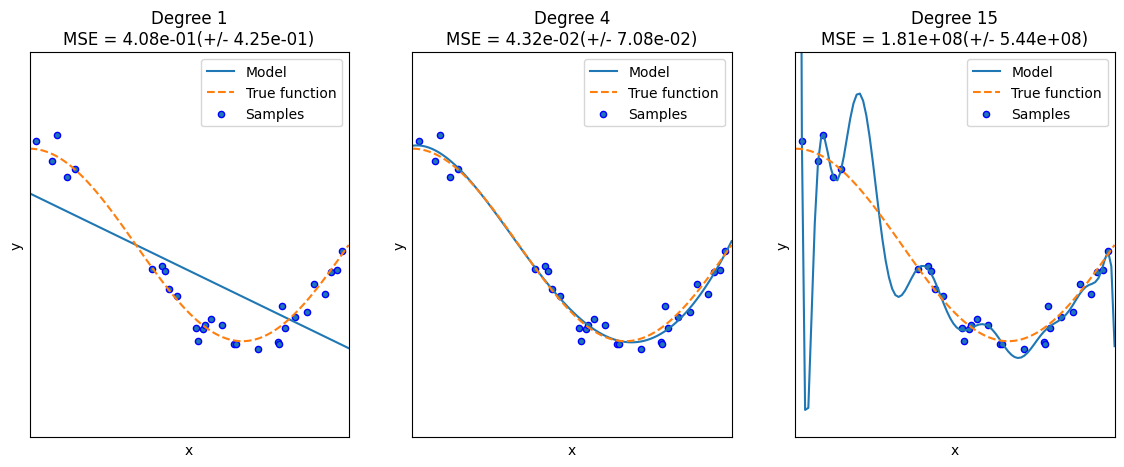

In [53]:
plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

# 다항 회귀의 차수(degree)를 1, 4, 15로 각각 변화시키면서 비교합니다.
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())
    
    # 개별 degree별로 Polynomial 변환합니다.
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X.reshape(-1, 1), y)
    
    # 교차 검증으로 다항 회귀를 평가합니다.
    scores = cross_val_score(pipeline, X.reshape(-1, 1), y, scoring="neg_mean_squared_error", cv=10)
    # Pipeline을 구성하는 세부 객체를 접근하는 named_steps['객체명']을 이용해 회귀계수 추출
    coefficients = pipeline.named_steps['linear_regression'].coef_
    print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {0} MSE 는 {1} 입니다.'.format(degrees[i], -1*np.mean(scores)))
          
    # 0 부터 1까지 테스트 데이터 세트를 100개로 나눠 예측을 수행합니다.
    # 테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교합니다.
    X_test = np.linspace(0, 1, 100)
    # 예측값 곡선
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    # 실제 값 곡선
    plt.plot(X_test, true_fun(X_test), '--', label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x"); plt.ylabel("y"); plt.xlim((0, 1)); plt.ylim((-2, 2)); plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(degrees[i], -scores.mean(), scores.std()))
    
plt.show()

실선으로 표현된 예측 곡선은 다항 회귀 예측 곡선임. 점선으로 표현된 곡선은 실제 데이터 세트 X,Y의 코사인 곡선임.

학습 데이터는 0부터 1까지의 30개의 임의의 X 값과 그에 따른 코사인 Y값에 잡음을 변동 값으로 추가해 구성했으며,

MSE 평가는 학습 데이터를 10개의 교차 검증 세트로 나누어 측정하여 평균한 것임

### 편향-분산 Trade off

앞의 Degree1과 같은 모델은 지나치게 한 방향성으로 치우친 경향이 있음 => 고편향(High Bias)성을 가졌다고 표현함. 

Degree15는 매우 복잡한 모델이 되었고 매우 높은 변동성을 가지게 됨 => 고분산(High Variance)성을 가졌다고 표현함.

일반적으로 편향과 분산은 trade off 관계가 존재함.

높은 편향/낮은 분산에서 과소적합되기 쉬우며, 낮은 편향/높은 분산에서 과적합되기 쉬움.